In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


### Main objective of Heavy Equipment Selling Price Prediction Challenge :
Explore this rich multi-modal dataset, discover latent patterns across numerical, categorical, and high-cardinality technical string features, and build robust predictive models to forecast the target financial or operational variable.



#  1. Loading Datasets

In [2]:
meta_path = '/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv'
train_path = '/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv'
test_path = '/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv'

train= pd.read_csv(train_path, low_memory=False)
test = pd.read_csv(test_path)

print(f"Initial shape of train dataset : {train.shape}")
print(f"Initial shape test dataset: {test.shape}")


Initial shape of train dataset : (138701, 50)
Initial shape test dataset: (15000, 49)


# 2. Importing necessary libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, ShuffleSplit, RandomizedSearchCV, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder,TargetEncoder, OneHotEncoder
from sklearn.metrics import root_mean_squared_log_error,mean_absolute_error,mean_squared_error


from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import early_stopping, log_evaluation


# 3. Exploratory Data Analysis

## Identify Data types of different columns of dataset

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

## Numerical and categorical features

In [5]:
num = train.select_dtypes(include=['int64','float64']).columns
print(num)
print(f"Number of Numerical features:",len(num))

Index(['TransactionID', 'TargetValue', 'AssetID', 'ProductConfigID',
       'ManufactureYear', 'OperationalHoursMeter'],
      dtype='object')
Number of Numerical features: 6


In [6]:
# Categorical features
cat = train.select_dtypes(include='object').columns
print(cat)
print(f"Number of categorical features:",len(cat))

Index(['DataOriginCode', 'VendorPartnerID', 'UtilizationTier',
       'TransactionDate', 'Spec_FullDescriptor', 'Spec_BaseClass',
       'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier',
       'AssetScaleFactor', 'FunctionalClassification', 'RegionCode',
       'InventoryGroupCategory', 'InventoryGroupDescription', 'col1',
       'CabinType', 'Forks', 'col3', 'col4', 'DrivetrainType', 'col5', 'col6',
       'col7', 'col8', 'col9', 'col10', 'col11', 'col12', 'col13', 'col14',
       'col15', 'col16', 'col18', 'col19', 'col20', 'col21', 'col22', 'col23',
       'col24', 'col25', 'col27', 'col28', 'col29', 'col30'],
      dtype='object')
Number of categorical features: 44


## Descriptive statistics of numerical columns

In [7]:
train.drop(['TransactionID','AssetID','ProductConfigID'],axis=1).describe().T

,count,mean,std,min,25%,50%,75%,max
TargetValue,138701.0,41521.874047,26361.125948,7500.0,20500.0,35000.0,57000.0,142000.0
ManufactureYear,138701.0,1891.640853,306.992001,1001.0,1990.0,1998.0,2004.0,2015.0
OperationalHoursMeter,82058.0,4553.718943,27922.044850,0.0,0.0,1620.0,5001.0,1729600.0


* The descriptive statistics provides some insights on Average price of equipment.
* The price of equipment vary in price ranging from 7500USD to 142000 USD
* We can infer mininmum or maximum age of equipment is old using ManufactureYear statistics.
* OperationalHoursMeter statistics infer how long machine is run on an average.

## Univariate and Bivariate analysis


* Univariate Analysis : Analysing the features individually using histogram plots.
  Currently, we have three numerical values TargetValue, ManufactureYear, and OperationalHoursMeter 
* Bivariate/Multivariate Analysis : Exploring relationships between variables using scatterplots and correlation matrices.
  

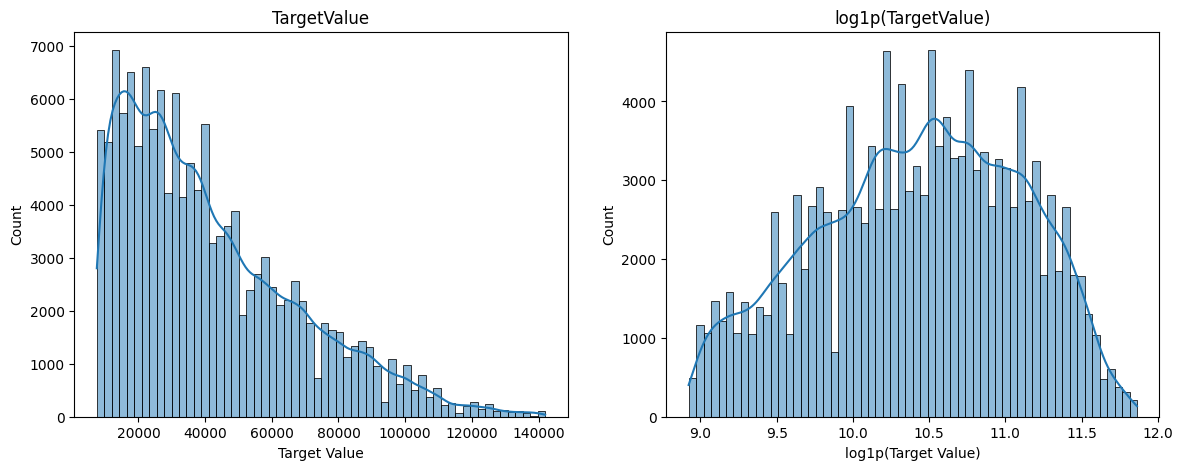

In [8]:
# Target value frequency plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train['TargetValue'], bins=60, kde=True, ax=axes[0])
axes[0].set_title('TargetValue')
axes[0].set_xlabel('Target Value')

sns.histplot(np.log1p(train['TargetValue']), bins=60, kde=True, ax=axes[1])
axes[1].set_title('log1p(TargetValue)')
axes[1].set_xlabel('log1p(Target Value)')

plt.show()


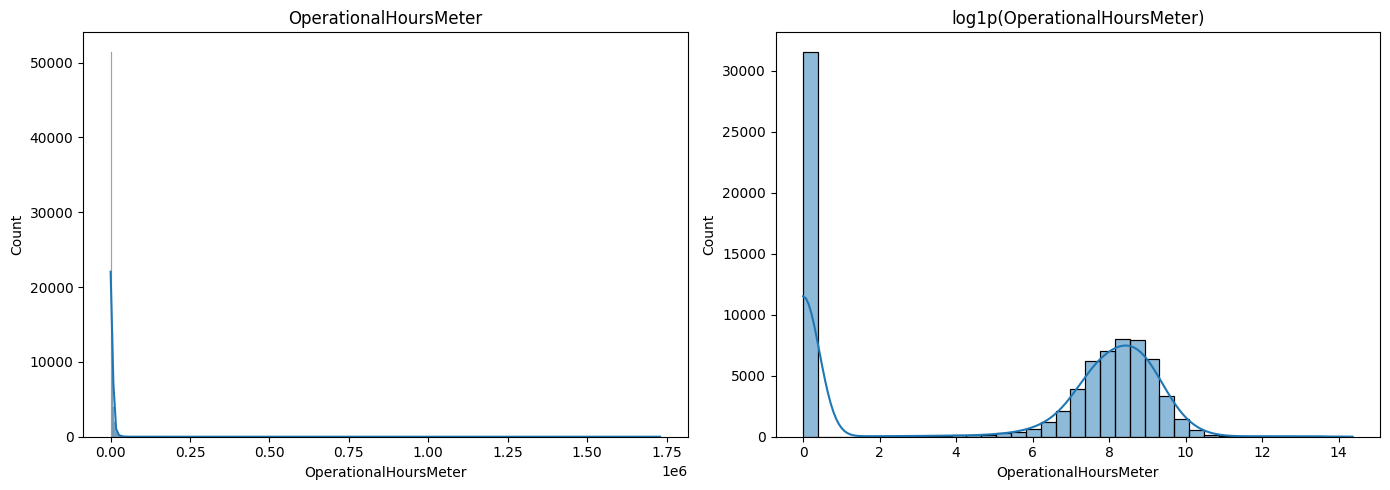

In [9]:
# OperationalHours frequency plot
fig, axes = plt.subplots(1,2, figsize = (14,5))
sns.histplot(train['OperationalHoursMeter'], kde=True, ax=axes[0])
axes[0].set_title('OperationalHoursMeter')
axes[0].set_xlabel('OperationalHoursMeter')

sns.histplot(np.log1p(train['OperationalHoursMeter']), kde=True, ax=axes[1])
axes[1].set_title('log1p(OperationalHoursMeter)')
axes[1].set_xlabel('OperationalHoursMeter')
plt.tight_layout()
plt.show()


Observation:
* TargetValue is right-skewed(long tail of expensive equipments)
* log1p transformation brings it much closer to symmetric, which is why the 
  model is trained on log1p(TargetValue) and predictions are inverted with expm1() 
  before scoring. This is also exactly why RMSLE is evaluation metric.
  
* Most heavy equipments sold are lower priced around USD15,000–40,000 .
* There are progressively fewer pieces of equipment at higher prices, with some
  reaching around 40,000.                                                         

Observation:
* The distribution of the Operational Hours Meter is highly right skewed.
* Most equipments having relatively low operating hours and a small number of observations exhibiting extremely large operational hours.
* log1p transformation of Operational hours brings out active run-time logged by the machines that lies roughly between 7 and 10, giving a much more symmetric distribution.
* There is still a very large spike at 0
    * Machines that genuinely have 0 operating hours (brand new).
    * Missing hour-meter readings that have been recorded as 0.   
  

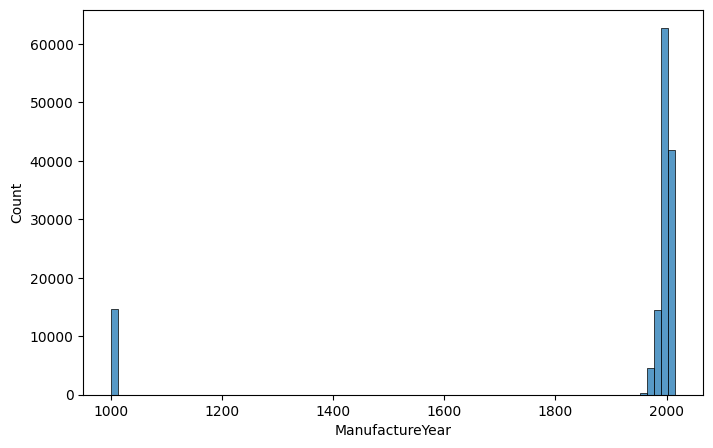

In [10]:
# ManufactureYear frequency plot
plt.figure(figsize=(8,5))
sns.histplot(train['ManufactureYear'],bins=80)
plt.show()


Observation:
* The majority of manufacturing occured around year 1998-2002 as there is a spike of approximately   58000 equipments.
* There is an anomoly which is year 1001, in which around 15000 equipments manufactured. 
* This has to handled for any data errors or this could be a place holder for unavailable year of manufacturing.
  

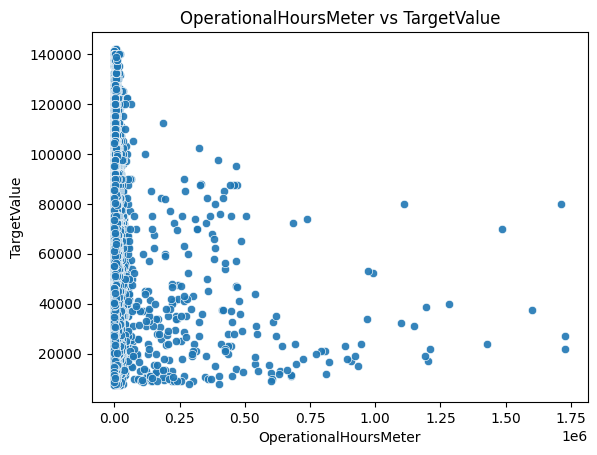

In [11]:
# Bivariate Analysis
sns.scatterplot(data = train,x='OperationalHoursMeter',y="TargetValue",palette= 'blue', alpha=0.9)
plt.xlabel("OperationalHoursMeter")
plt.ylabel("TargetValue")
plt.title("OperationalHoursMeter vs TargetValue")

plt.show()


Observation: 
The data is heavily concentrated at low operating hours. There is a slight tendency for selling price to decrease as operating hours increase, but the relationship is weak, suggesting that additional features are needed to accurately predict equipment prices.

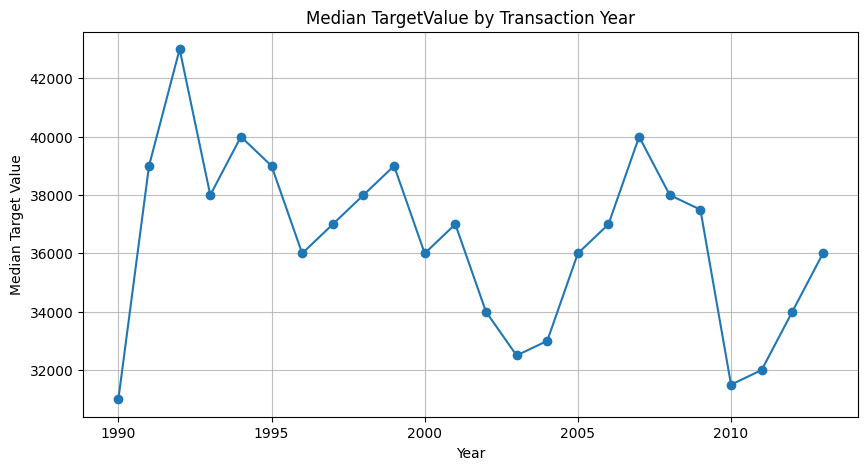

In [12]:
# Bivariate Analysis
train_dates = train.copy()
train_dates['TransactionDate'] = pd.to_datetime(train_dates['TransactionDate'], format='%Y-%m-%d')
train_dates['TransactionYear'] = train_dates['TransactionDate'].dt.year
train_dates['TransactionMonth'] = train_dates['TransactionDate'].dt.month

yearly_price = train_dates.groupby('TransactionYear')['TargetValue'].median()

plt.figure(figsize=(10, 5))
yearly_price.plot(marker='o')
plt.title('Median TargetValue by Transaction Year')
plt.xlabel('Year')
plt.ylabel('Median Target Value')
plt.grid(alpha=0.8)
plt.show()

Observation:
* The average selling price generally increases with the manufacture year, indicating that newer equipment tends to have a higher market value than older equipment. 
This trend suggests that equipment age is an important factor influencing the target value. 
* The invalid manufacture year value (1001) was excluded from the analysis as it represents erroneous or missing data and would otherwise distort the visualization.

### Visual analysis of categorical features

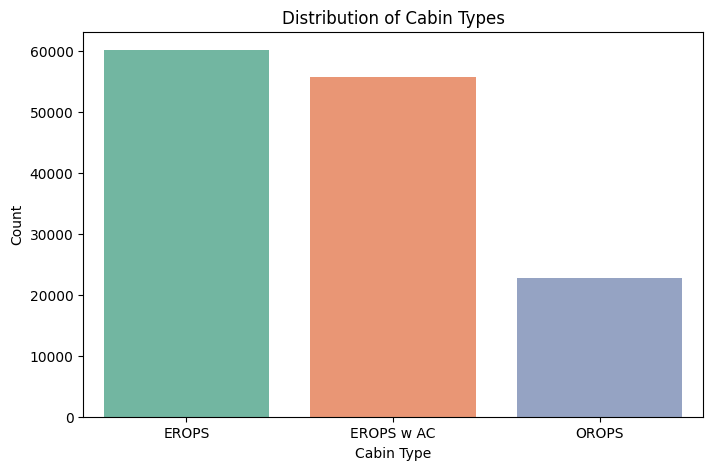

In [13]:
# Countplot for CabinType
plt.figure(figsize=(8,5))
sns.countplot(
    data=train,
    x="CabinType",
    order=train["CabinType"].value_counts().index,
    palette="Set2"
)

plt.title("Distribution of Cabin Types")
plt.xlabel("Cabin Type")
plt.ylabel("Count")

plt.show()

Observation:

* The countplot shows the distribution of different cabin types in the dataset[EROPS, EROPS w AC and OROPS]. 
* Most machines are equipped with EROPS (Enclosed Rollover Protective Structure) or EROPS with Air Conditioning, indicating that enclosed operator cabins with rollover protection are common. 
* OROPS represents machines with an open operator station protected only by a rollover structure, while a small proportion of records have unspecified cabin type information.

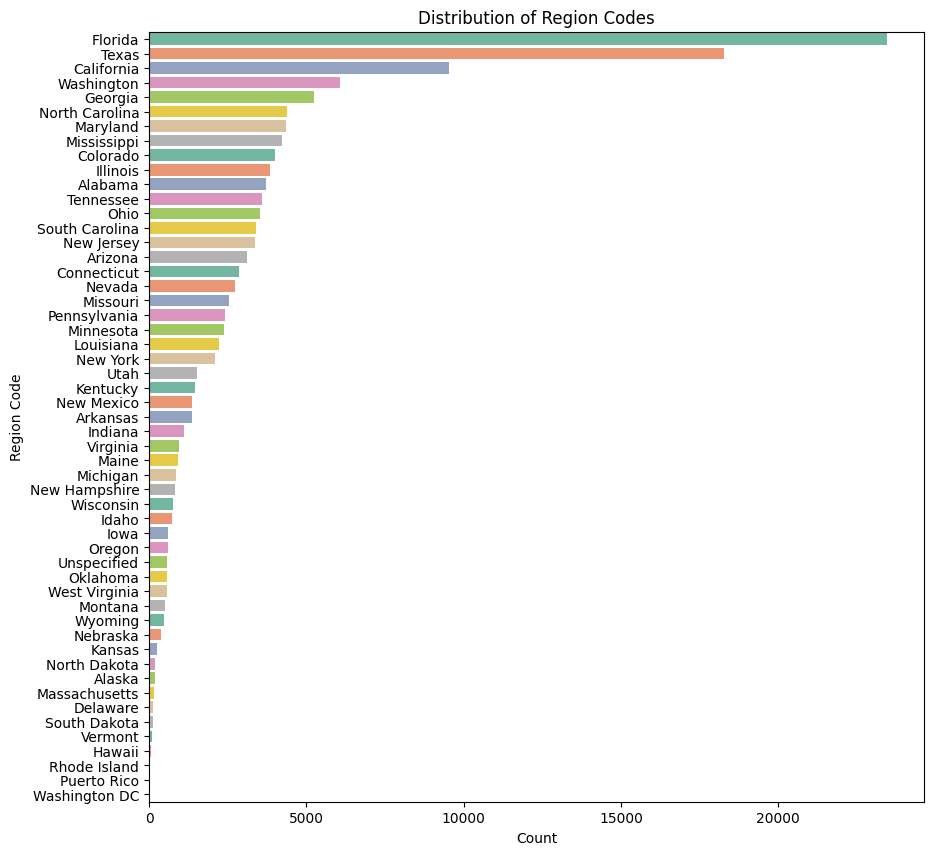

In [14]:
# Plot for RegionCode vs TargetValue

plt.figure(figsize=(10, 10))

sns.countplot(
    data=train,
    y="RegionCode",
    order=train["RegionCode"].value_counts().index,
    palette="Set2"
)

plt.title("Distribution of Region Codes")
plt.xlabel("Count")
plt.ylabel("Region Code")

plt.show()

Obsevation:
* The Count plot shows pricing insights regionwise.
The region from where most of the machines sold is **Florida**.


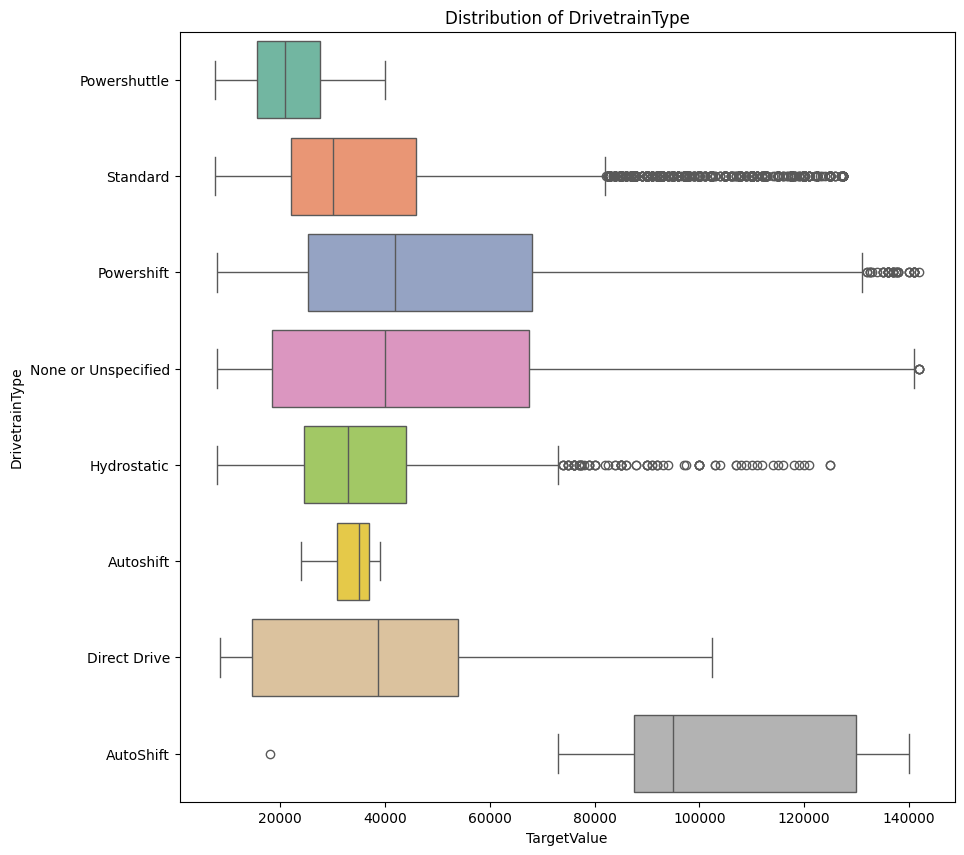

In [15]:
#Plot for Distribution of DrivetrainType
plt.figure(figsize=(10, 10))

sns.boxplot(
    data=train,
    x = "TargetValue",
    y="DrivetrainType",    
    palette="Set2"
)

plt.title("Distribution of DrivetrainType")
plt.xlabel("TargetValue")
plt.ylabel("DrivetrainType")

plt.show()

Observation:
The distribution of selling prices differs among drivetrain types, with several categories exhibiting a wide range of prices and the presence of outliers.

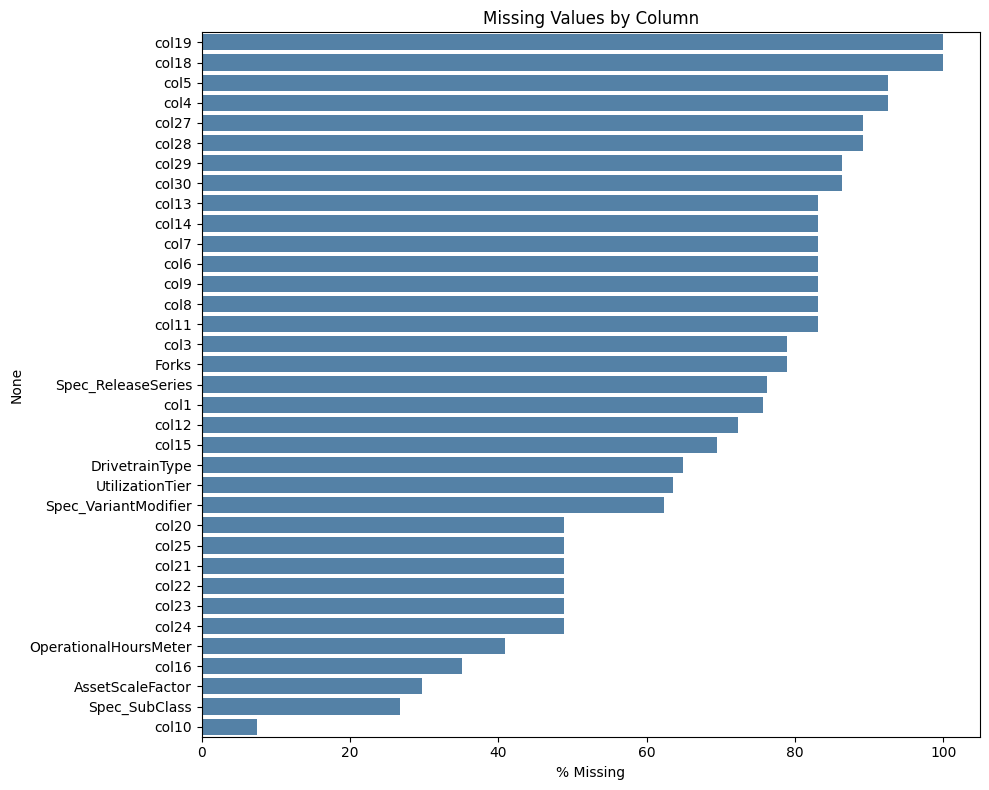

In [16]:
missing_pct = (train.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(10,8))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color='steelblue')
plt.xlabel('% Missing')
plt.title('Missing Values by Column')
plt.tight_layout()
plt.show()


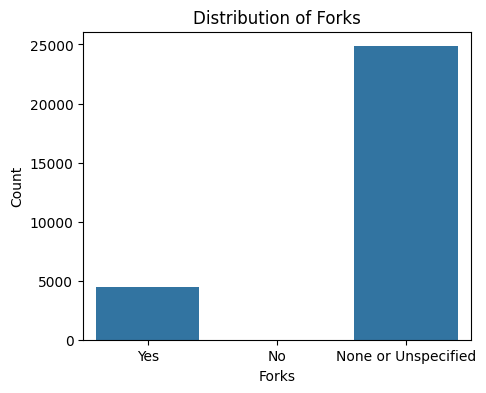

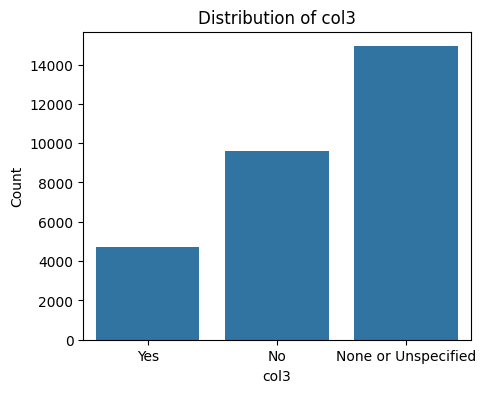

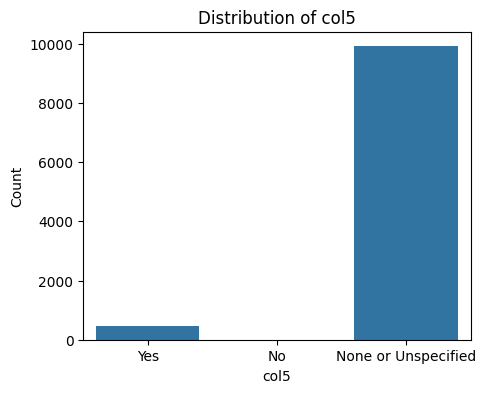

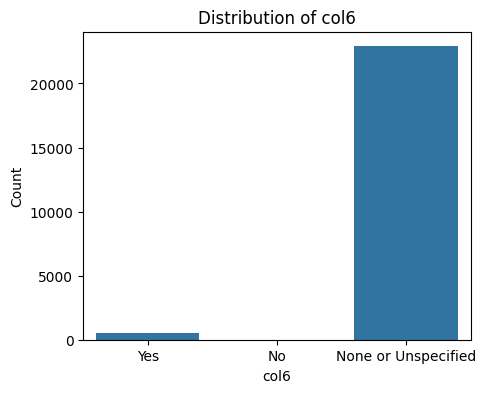

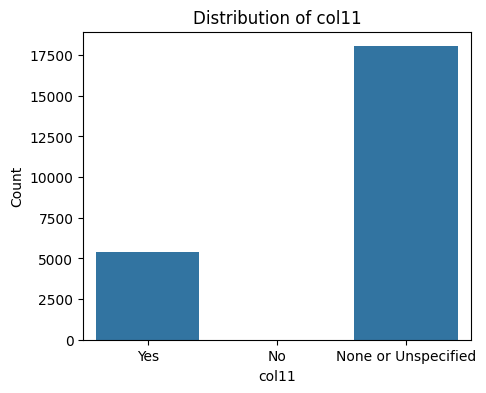

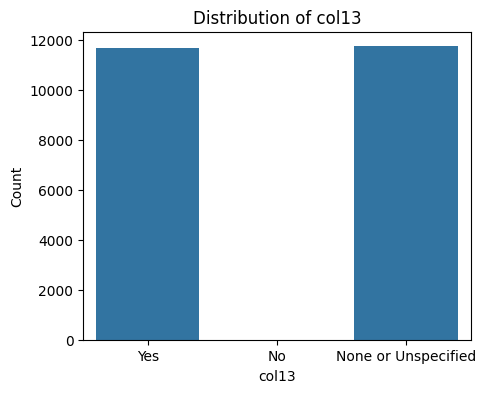

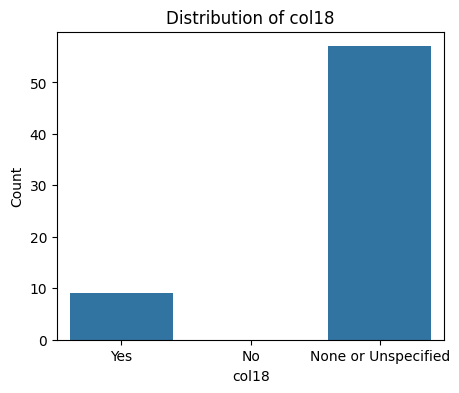

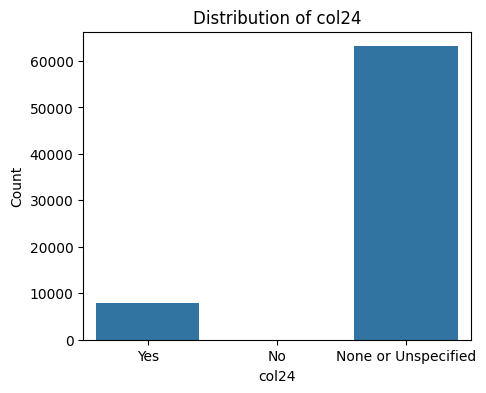

In [17]:
#Identifying possible values of 'Yes', 'No' and 'None or Unspecified'

possible_values = {"Yes", "No", "None or Unspecified"}

for col in train.select_dtypes(include="object").columns:   
    unique_vals = set(train[col].dropna().unique())

    if unique_vals.issubset(possible_values):
        plt.figure(figsize=(5,4))

        sns.countplot(
            data=train,
            x=col,
            order=["Yes", "No", "None or Unspecified"]
        )
        
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()
        

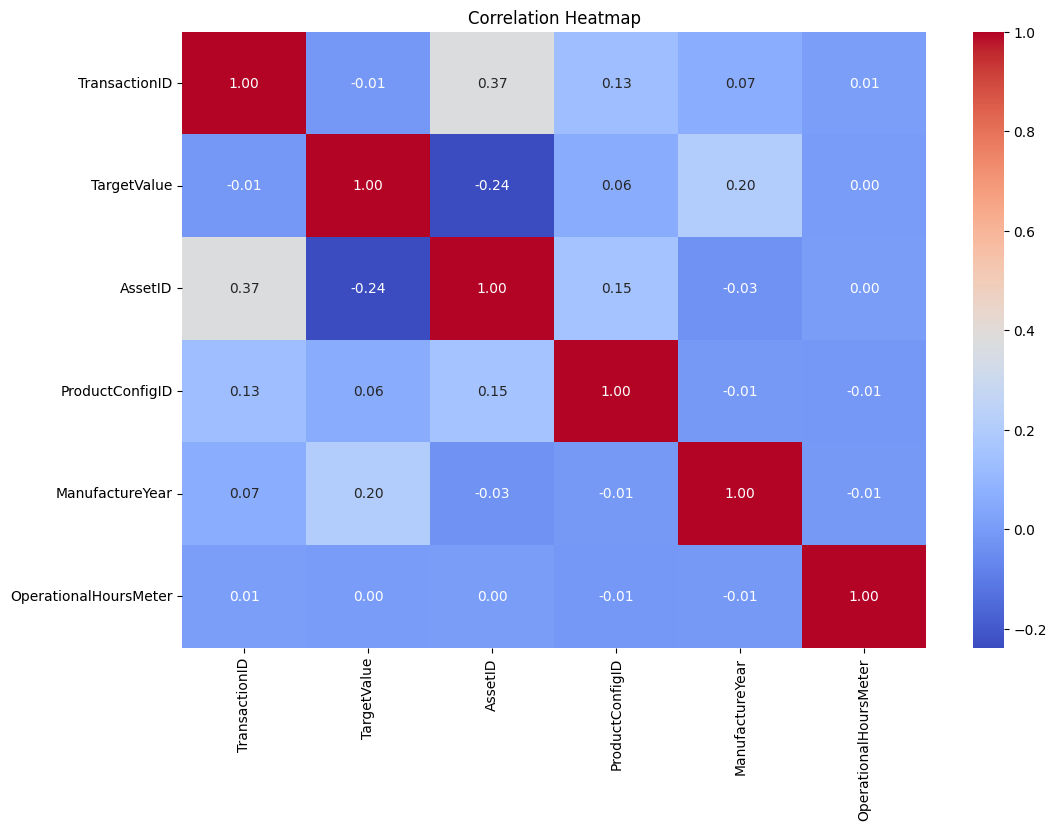

In [18]:
# Correlation matrix for Numerical columns
corr_matrix = train.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Inferences from the Correlation Matrix:**

* **ManufactureYear** shows a weak positive correlation (0.20) with the target variable, indicating that newer equipment generally are of higher selling prices than older equipment. To better capture the effect of age, an AssetAge feature was created by subtracting the manufacture year from the transaction year.
* 
* **ProductConfigID** has a very weak positive correlation (0.06) with the target value. Since this feature is a categorical identifier rather than a continuous numerical variable, correlation is not an appropriate measure of its predictive power.
* 
* **OperationalHoursMeter** has an almost zero linear correlation (0.00) with the target value. This does not necessarily mean the feature is unimportant, as the relationship between operating hours and selling price is likely to be nonlinear. To capture this relationship more effectively, a derived feature such as HoursPerYear (OperationalHoursMeter ÷ AssetAge) can be created.
* 
* **AssetID** exhibits a weak negative correlation (-0.24) with the target value. However, as it is merely a unique identifier, this correlation is likely coincidental and does not provide meaningful predictive information. Hence, AssetID can be removed from the model.
* 
* **TransactionID** has a negligible correlation (-0.01) with the target value. Similar to AssetID, it is a unique identifier and does not contribute to prediction. Therefore, TransactionID was also dropped during preprocessing.

# 4. Preprocessing

## Identify duplicates and handling

In [19]:
# Find the number of duplicates present in train dataset without 'TransactionID'

train_df = train.drop('TransactionID', axis=1)
train_df.duplicated().sum()

print('Duplicates of training data :', train_df.duplicated().sum())

Duplicates of training data : 0


In [20]:
#Handling Duplicates
train = train.drop_duplicates()
train.shape

(138701, 50)

## Identify unique values for features separating low cardinality and high cardinality features

In [21]:
# Numerical features
num = train.select_dtypes(include='number').columns
print(f"Number of Numerical features:",len(num))
print(num)
# Categorical features
cat = train.select_dtypes(include='object').columns
print(f"Number of categorical features:",len(cat))
print(cat)

Number of Numerical features: 6
Index(['TransactionID', 'TargetValue', 'AssetID', 'ProductConfigID',
       'ManufactureYear', 'OperationalHoursMeter'],
      dtype='object')
Number of categorical features: 44
Index(['DataOriginCode', 'VendorPartnerID', 'UtilizationTier',
       'TransactionDate', 'Spec_FullDescriptor', 'Spec_BaseClass',
       'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier',
       'AssetScaleFactor', 'FunctionalClassification', 'RegionCode',
       'InventoryGroupCategory', 'InventoryGroupDescription', 'col1',
       'CabinType', 'Forks', 'col3', 'col4', 'DrivetrainType', 'col5', 'col6',
       'col7', 'col8', 'col9', 'col10', 'col11', 'col12', 'col13', 'col14',
       'col15', 'col16', 'col18', 'col19', 'col20', 'col21', 'col22', 'col23',
       'col24', 'col25', 'col27', 'col28', 'col29', 'col30'],
      dtype='object')


## Identify missing values and handling

In [22]:
train.isna().sum().sort_values(ascending=False)

col19                        138635
col18                        138635
col5                         128320
col4                         128320
col27                        123742
col28                        123742
col29                        119829
col30                        119829
col13                        115296
col14                        115296
col7                         115296
col6                         115296
col9                         115296
col8                         115296
col11                        115296
col3                         109448
Forks                        109382
Spec_ReleaseSeries           105805
col1                         104915
col12                        100337
col15                         96424
DrivetrainType                89956
UtilizationTier               88226
Spec_VariantModifier          86369
col20                         67685
col25                         67685
col21                         67685
col22                       

In [23]:
# Drop columns with >90% missing values

missing_percent = train.isnull().mean()

# Identify remaining missing columns

missing_cols = train.columns[train.isnull().any()].tolist()

num_cols_null = train[missing_cols].select_dtypes(include=["number"]).columns.tolist()
cat_cols_null = train[missing_cols].select_dtypes(include="object").columns.tolist()

print("Numeric columns with missing values:")
print(num_cols_null)

print("\nCategorical columns with missing values:")
print(cat_cols_null)

# Impute missing values

num_imputer = SimpleImputer(strategy="mean")
cat_imputer = SimpleImputer(strategy="most_frequent")

train[num_cols_null] = num_imputer.fit_transform(train[num_cols_null])
test[num_cols_null] = num_imputer.transform(test[num_cols_null])

train[cat_cols_null] = cat_imputer.fit_transform(train[cat_cols_null])
test[cat_cols_null] = cat_imputer.transform(test[cat_cols_null])

Numeric columns with missing values:
['OperationalHoursMeter']

Categorical columns with missing values:
['UtilizationTier', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor', 'col1', 'Forks', 'col3', 'col4', 'DrivetrainType', 'col5', 'col6', 'col7', 'col8', 'col9', 'col10', 'col11', 'col12', 'col13', 'col14', 'col15', 'col16', 'col18', 'col19', 'col20', 'col21', 'col22', 'col23', 'col24', 'col25', 'col27', 'col28', 'col29', 'col30']


In [24]:
# Check after imputing for any null values present
missing_percent = train.isnull().sum().sort_values(ascending=False)/len(train) *100
missing_percent   

TransactionID                0.0
TargetValue                  0.0
AssetID                      0.0
ProductConfigID              0.0
DataOriginCode               0.0
VendorPartnerID              0.0
ManufactureYear              0.0
OperationalHoursMeter        0.0
UtilizationTier              0.0
TransactionDate              0.0
Spec_FullDescriptor          0.0
Spec_BaseClass               0.0
Spec_SubClass                0.0
Spec_ReleaseSeries           0.0
Spec_VariantModifier         0.0
AssetScaleFactor             0.0
FunctionalClassification     0.0
RegionCode                   0.0
InventoryGroupCategory       0.0
InventoryGroupDescription    0.0
col1                         0.0
CabinType                    0.0
Forks                        0.0
col3                         0.0
col4                         0.0
DrivetrainType               0.0
col5                         0.0
col6                         0.0
col7                         0.0
col8                         0.0
col9      

****

## Handling outliers

In [25]:
# Identify outliers

outliers_details = []

numeric_cols = train.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = ((train[col] < lower_bound) | (train[col] > upper_bound)).sum()
    outlier_percent = (outlier_count / len(train)) * 100

    outliers_details.append({
        "Feature": col,
        "Outliers": outlier_count,
        "Percentage (%)": round(outlier_percent, 2)
    })

outlier_df = pd.DataFrame(outliers_details)
outlier_df = outlier_df.sort_values(by="Percentage (%)", ascending=False)

print(outlier_df)

                 Feature  Outliers  Percentage (%)
2                AssetID     19565           14.11
0          TransactionID     17280           12.46
4        ManufactureYear     16026           11.55
5  OperationalHoursMeter      6704            4.83
3        ProductConfigID      2232            1.61
1            TargetValue      1986            1.43


Outlier Analysis:

* Outliers were identified using the Interquartile Range (IQR) method for the numerical features. * The highest proportion of outliers was observed in TransactionIsWeekend (24.09%), followed by AssetID (14.11%), TransactionID (12.46%), and ManufactureYear (11.55%). OperationalHoursMeter contained 4.83% outliers, while ProductConfigID (1.61%) and the target variable TargetValue (1.43%) exhibited relatively few outliers.
* Since TransactionID and AssetID are identifier variables, their outliers are not meaningful for predictive modelling.
* The outliers in OperationalHoursMeter, ManufactureYear, and TargetValue likely represent genuine variations in equipment age, usage, and selling price rather than data errors. Therefore, these observations were retained for model training, while anomalous placeholder values in ManufactureYear (e.g., 1001) were handled separately during preprocessing.

In [26]:
# handling special characters
special_cols = []

for col in train.select_dtypes(include="object").columns:
    if train[col].astype(str).str.contains(r"[^a-zA-Z0-9\s-]", regex=True, na=False).any():
        special_cols.append(col)

print(special_cols)

['VendorPartnerID', 'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor', 'FunctionalClassification', 'col7', 'col10', 'col14', 'col15', 'col22']


In [27]:
# Parsing measurement columns and special chars

def parse_measurement(value):
    if pd.isna(value):
        return np.nan

    s = str(value).strip().lower()

    # Handle missing values
    if s in ["none or unspecified", "variable", ""]:
        return np.nan

    # Remove special symbols and  keep ' and "
    s = re.sub(r"[<>\[\]]", "", s).strip()

    # Handle feet and inches (e.g., 9' 6", 11' 0")
    match = re.match(r"(\d+(?:\.\d+)?)\s*'\s*(\d+(?:\.\d+)?)?\s*\"?$", s)
    if match:
        feet = float(match.group(1))
        inches = float(match.group(2)) if match.group(2) else 0
        return feet * 12 + inches

    # Handle feet only (e.g., 12')
    match = re.match(r"(\d+(?:\.\d+)?)\s*'$", s)
    if match:
        return float(match.group(1)) * 12

    # Handle inches only (e.g., 13", 17.5")
    match = re.match(r"(\d+(?:\.\d+)?)\s*\"$", s)
    if match:
        return float(match.group(1))

    # Handle "32 inch", "32 inches", "32 in"
    match = re.match(r"(\d+(?:\.\d+)?)\s*(inch|inches|in)\b", s)
    if match:
        return float(match.group(1))

    # Handle plain numeric values (e.g., 23.5, 32)
    try:
        return float(s)
    except ValueError:
        return np.nan

In [28]:
# Handling columns with measurement values
measurement_cols = ["col7", "col10", "col14", "col15", "col21", "col22"]

for df in [train, test]:
    for col in measurement_cols:
        df[col] = df[col].apply(parse_measurement).astype(float) 

special_cols = [col for col in special_cols if col not in measurement_cols]
print(special_cols) # ready for target encoding

['VendorPartnerID', 'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor', 'FunctionalClassification']


In [29]:
# Handling 'None or Unspecified'values
for df in [train, test]:
    obj_cols = df.select_dtypes(include=["object","category"]).columns
    df[obj_cols] = df[obj_cols].replace({
        "None or Unspecified": np.nan,
        "Variable": np.nan
    })

In [30]:
#Identyfying 'Yes' and 'No' from respective columns
yes_no_cols = []

for col in train.select_dtypes(include="object").columns:
    values = set(train[col].dropna().unique())

    if values.issubset({"Yes", "No"}):
        yes_no_cols.append(col)

print(yes_no_cols)

['Forks', 'col3', 'col5', 'col6', 'col9', 'col11', 'col13', 'col18', 'col24']


In [31]:
# Binary mapping for columns with 'Yes' and 'No'
binary_map = {"Yes": 1, "No": 0}

for df in [train, test]:
    df[yes_no_cols] = df[yes_no_cols].replace(binary_map)

train[yes_no_cols][:5] # ready for model    

,Forks,col3,col5,col6,col9,col11,col13,col18,col24
0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
1,NaN,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
3,NaN,0.0,1.0,NaN,0.0,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


# 5. Feature Engineering


## Date feature handling(Extracting, year,day,month etc from existing'TransactionDate' feature)

In [32]:
# Date feature Handling

def date_features(df, date_col="TransactionDate", drop_original=False):
    df = df.copy()

    df[date_col] = pd.to_datetime(df[date_col], format="%Y-%m-%d", errors="coerce")

    df["TransactionYear"] = df[date_col].dt.year
    df["TransactionQuarter"] = df[date_col].dt.quarter
    df["TransactionMonth"] = df[date_col].dt.month
    df["TransactionDay"] = df[date_col].dt.day
    df["TransactionDayOfWeek"] = df[date_col].dt.dayofweek
    df["TransactionIsWeekend"] = (df["TransactionDayOfWeek"] >= 5).astype(int)

    if drop_original:
        df.drop(columns=[date_col], inplace=True)

    return df
train = date_features(train, drop_original=True)
test = date_features(test, drop_original=True)

# Replace invalid ManufactureYear
for df in [train, test]:
    df["ManufactureYear"] = df["ManufactureYear"].replace(1001, np.nan)

# Fill missing ManufactureYear using training median
median_year = train["ManufactureYear"].median()

for df in [train, test]:
    df["ManufactureYear"] = (
        df["ManufactureYear"]
        .fillna(median_year)
        .astype(int)
    )


Handling Invalid Manufacture Year

- Replaced invalid `ManufactureYear` values (`1001`) with missing values (`NaN`).
- Imputed missing manufacture years using the **median manufacture year** computed from the training dataset.
- Converted the imputed values back to integer type.


## Added new features derived from existing features
* 'AssetAge'
* 'HasOperationalHours'
* 'LogOperationalHours'
* 'HoursPerYear'
* 'DescriptorLength'
* 'HasVariantModifier"
* 'HasReleaseSeries'
  

In [33]:
# Adding more new features 

for df in [train, test]:

    # Asset Age
    df["AssetAge"] = (df["TransactionYear"] - df["ManufactureYear"])
    # Prevent negative or zero age
    df["AssetAge"] = df["AssetAge"].clip(lower=1)


    df["HasOperationalHours"] = (df["OperationalHoursMeter"].notna().astype(int))

    # Log of Operational Hours
    df["LogOperationalHours"] = np.log1p(df["OperationalHoursMeter"].fillna(0))

    # Hours Per Year
    df["HoursPerYear"] = (df["OperationalHoursMeter"] / df["AssetAge"])

    # Replace infinities with NaN
    df["HoursPerYear"] = (df["HoursPerYear"].replace([np.inf, -np.inf], np.nan))

    # Length of Full Descriptor
    df["DescriptorLength"] = (df["Spec_FullDescriptor"].astype(str).str.len())

    # Missing value indicators
    df["HasVariantModifier"] = (df["Spec_VariantModifier"].notna().astype(int))
    df["HasReleaseSeries"] = (df["Spec_ReleaseSeries"].notna().astype(int))

# Fill HoursPerYear using training median
median_hours = train["HoursPerYear"].median()

for df in [train, test]:
    df["HoursPerYear"] = df["HoursPerYear"].fillna(median_hours)

* *Date based feature*

* **Asset Age**
-Created a new feature representing the age of the equipment at the time of transaction.
`AssetAge = TransactionYear − ManufactureYear`
- Values less than 1 were clipped to 1 to avoid zero or negative ages.

---
* *Operational Hours Features*

* **HasOperationalHours**
-Created a binary indicator showing whether an operational hours reading is available
 1 -> Operational hours available 
 0 -> Operational hours missing
  
* **LogOperationalHours**

-Applied the `log1p` transformation to reduce the right-skewness of `OperationalHoursMeter`.
- Missing values were replaced with zero before applying the transformation.

* **HoursPerYear**

-Created a utilization feature:
`HoursPerYear = OperationalHoursMeter / AssetAge`

- Infinite values resulting from division were replaced with missing values.
- Missing values were imputed using the median value calculated from the training dataset.

---
* *Descriptor-Based Feature* 

* **DescriptorLength**

Created a numerical feature representing the number of characters in `Spec_FullDescriptor`.
This feature captures the complexity or specificity of the equipment description.

---

* *Missing Value Indicator Features*

Binary indicator variables were created to preserve information about missing specification fields.

* **HasVariantModifier**
1 -> Variant modifier available 
0 -> Variant modifier missing |
___

* **HasReleaseSeries**
 1 -> Release series available 
 0 -> Release series missing 

These indicator variables allow the model to learn whether the absence of specification information carries predictive value.


## Numerical and categorical features after preprocessing and feature engineering

In [34]:
# Numerical and categorical features after preprocessing and feature engineering
num_cols = train.select_dtypes(include="number").columns.tolist()
num_cols.remove("TargetValue")
num_cols.remove("TransactionID")

cat_cols = train.select_dtypes(include=["object"]).columns

low_card_cols = [col for col in cat_cols if train[col].nunique(dropna=True) <= 15]
high_card_cols = [col for col in cat_cols if train[col].nunique(dropna=True) > 15]
print(low_card_cols)
print(high_card_cols)
print(num_cols)
print(len(low_card_cols))
print(len(high_card_cols)) 
print(len(num_cols))

['DataOriginCode', 'UtilizationTier', 'AssetScaleFactor', 'InventoryGroupCategory', 'InventoryGroupDescription', 'col1', 'CabinType', 'col4', 'DrivetrainType', 'col8', 'col12', 'col16', 'col19', 'col20', 'col23', 'col25', 'col27', 'col28', 'col29', 'col30']
['VendorPartnerID', 'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'FunctionalClassification', 'RegionCode']
['AssetID', 'ProductConfigID', 'ManufactureYear', 'OperationalHoursMeter', 'Forks', 'col3', 'col5', 'col6', 'col7', 'col9', 'col10', 'col11', 'col13', 'col14', 'col15', 'col18', 'col21', 'col22', 'col24', 'TransactionYear', 'TransactionQuarter', 'TransactionMonth', 'TransactionDay', 'TransactionDayOfWeek', 'TransactionIsWeekend', 'AssetAge', 'HasOperationalHours', 'LogOperationalHours', 'HoursPerYear', 'DescriptorLength', 'HasVariantModifier', 'HasReleaseSeries']
20
8
32


## Implementing Pipeline

In [35]:
# Pipeline implementation

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

low_card_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore",
    sparse_output=False))
])

high_card_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("target", TargetEncoder())
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("low_cat", low_card_pipeline, low_card_cols),
    ("high_cat", high_card_pipeline, high_card_cols),
]).set_output(transform="pandas")

## Perform train test split after preprocessing and feature engineering

In [36]:
# Drop TargetValue
X = train.drop(columns=["TargetValue"])
y = np.log1p(train["TargetValue"])


# Split train test
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [37]:
X_train_transformed = preprocessor.fit_transform(X_train, y_train)
X_valid_transformed = preprocessor.transform(X_valid)

# 6. Model building and Evaluation
Four types of models have been used for evaluation
*  XGBRegressor
*  LGBMRegressor
*  CatBoostRegressor
  

## XGBRegressor

In [38]:
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_log_error

xgb_model = XGBRegressor(
    n_estimators=9000,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

xgb_model.fit(
    X_train_transformed,
    y_train,
    eval_set=[(X_valid_transformed, y_valid)],
    verbose=200
)

# Predict in log scale
y_pred_xgb = xgb_model.predict(X_valid_transformed)

# Convert predictions back to original scale
y_pred_xgb = np.expm1(y_pred_xgb)

# Convert validation target back to original scale
y_valid_actual = np.expm1(y_valid)

# Clip any negative predictions
y_pred_xgb = np.maximum(y_pred_xgb, 0)

# Calculate RMSLE
xgb_rmsle = root_mean_squared_log_error(
    y_valid_actual,
    y_pred_xgb
)

print("XGBoost RMSLE:", xgb_rmsle)

[0]	validation_0-rmse:0.65327
[200]	validation_0-rmse:0.22405
[400]	validation_0-rmse:0.21691
[600]	validation_0-rmse:0.21364
[800]	validation_0-rmse:0.21154
[1000]	validation_0-rmse:0.21015
[1200]	validation_0-rmse:0.20909
[1400]	validation_0-rmse:0.20828
[1600]	validation_0-rmse:0.20773
[1800]	validation_0-rmse:0.20717
[2000]	validation_0-rmse:0.20678
[2200]	validation_0-rmse:0.20642
[2400]	validation_0-rmse:0.20624
[2600]	validation_0-rmse:0.20596
[2800]	validation_0-rmse:0.20583
[3000]	validation_0-rmse:0.20561
[3200]	validation_0-rmse:0.20547
[3400]	validation_0-rmse:0.20535
[3600]	validation_0-rmse:0.20525
[3800]	validation_0-rmse:0.20514
[4000]	validation_0-rmse:0.20511
[4200]	validation_0-rmse:0.20507
[4400]	validation_0-rmse:0.20502
[4600]	validation_0-rmse:0.20496
[4800]	validation_0-rmse:0.20495
[5000]	validation_0-rmse:0.20489
[5200]	validation_0-rmse:0.20482
[5400]	validation_0-rmse:0.20477
[5600]	validation_0-rmse:0.20478
[5800]	validation_0-rmse:0.20474
[6000]	validation

## LGBMRegressor

In [39]:
# LGBM model

lgb_model = LGBMRegressor(
        n_estimators=9000,
        learning_rate=0.03,
        num_leaves=128,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.05,
        reg_lambda=0.1,
        random_state=42,
        n_jobs=-1
)

lgb_model.fit(
    X_train_transformed,
    y_train,
    eval_set=[(X_valid_transformed, y_valid)],
    eval_metric='rmse',
    callbacks=[
        early_stopping(200),
        log_evaluation(200)
    ]
)

# Predict in log scale
y_pred_lgb = lgb_model.predict(X_valid_transformed)

# Convert predictions back to original scale
y_pred_lgb = np.expm1(y_pred_lgb)

# Convert validation target back to original scale
y_valid_actual = np.expm1(y_valid)

# Clip any negative predictions
y_pred_lgb= np.maximum(y_pred_lgb, 0)

# Calculate RMSLE
lgb_rmsle = root_mean_squared_log_error(
    y_valid_actual,
    y_pred_lgb
)

print("LightGBM RMSLE:", lgb_rmsle)




[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028893 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3356
[LightGBM] [Info] Number of data points in the train set: 110960, number of used features: 96
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 10.424734
Training until validation scores don't improve for 200 rounds
[200]	valid_0's rmse: 0.2229	valid_0's l2: 0.0496842
[400]	valid_0's rmse: 0.215165	valid_0's l2: 0.0462959
[600]	valid_0's rmse: 0.212393	valid_0's l2: 0.0451108
[800]	valid_0's rmse: 0.210629	valid_0's l2: 0.0443647
[1000]	valid_0's rmse: 0.209293	valid_0's l2: 0.0438037
[1200]	valid_0's rmse: 0.208411	valid_0's l2: 0.0434353
[1400]	valid_0's rmse: 0.20765	valid_0's

## CatBoostRegressor

In [40]:
# CatBoost Model

cat_model = CatBoostRegressor(
    iterations=9000,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=200
)

cat_model.fit(
    X_train_transformed,
    y_train,
    eval_set=(X_valid_transformed, y_valid),
    use_best_model=True
)

# Predict in log scale
y_pred_cat = cat_model.predict(X_valid_transformed)

# Convert predictions back to original scale
y_pred_cat = np.expm1(y_pred_cat)

# Convert validation target back to original scale
y_valid_actual = np.expm1(y_valid)

# Clip any negative predictions
y_pred_cat= np.maximum(y_pred_cat, 0)

# Calculate RMSLE
cat_rmsle = root_mean_squared_log_error(
    y_valid_actual,
    y_pred_cat
)

print("CatBoost RMSLE:", cat_rmsle)

0:	learn: 0.6562217	test: 0.6542705	best: 0.6542705 (0)	total: 95.5ms	remaining: 14m 19s
200:	learn: 0.2504502	test: 0.2480791	best: 0.2480791 (200)	total: 6.41s	remaining: 4m 40s
400:	learn: 0.2360784	test: 0.2355935	best: 0.2355935 (400)	total: 12.4s	remaining: 4m 26s
600:	learn: 0.2272391	test: 0.2286685	best: 0.2286685 (600)	total: 18.6s	remaining: 4m 19s
800:	learn: 0.2213431	test: 0.2245710	best: 0.2245710 (800)	total: 24.5s	remaining: 4m 10s
1000:	learn: 0.2169706	test: 0.2219413	best: 0.2219413 (1000)	total: 30.4s	remaining: 4m 3s
1200:	learn: 0.2133852	test: 0.2199154	best: 0.2199154 (1200)	total: 36.2s	remaining: 3m 55s
1400:	learn: 0.2101724	test: 0.2183731	best: 0.2183731 (1400)	total: 42.1s	remaining: 3m 48s
1600:	learn: 0.2073235	test: 0.2171475	best: 0.2171475 (1600)	total: 48s	remaining: 3m 41s
1800:	learn: 0.2047555	test: 0.2161449	best: 0.2161448 (1799)	total: 53.9s	remaining: 3m 35s
2000:	learn: 0.2021883	test: 0.2151831	best: 0.2151831 (2000)	total: 59.6s	remaining:

## Comparison of 3 models XgBoost, LightGBM and Catboost rmsle scores

XGBoost  RMSLE : 0.2047646679208258
LightGBM RMSLE : 0.20346551726547882
CatBoost RMSLE : 0.20571118222606705


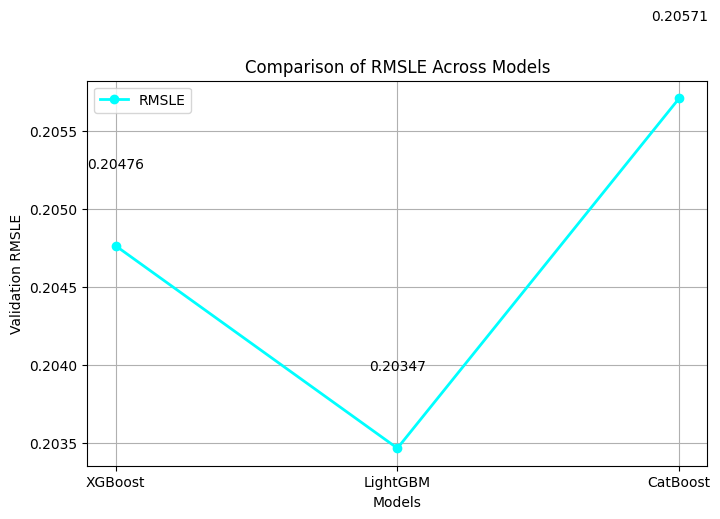

In [41]:
# Comparing all three model's RMSLE score

print("XGBoost  RMSLE :", xgb_rmsle)
print("LightGBM RMSLE :", lgb_rmsle)
print("CatBoost RMSLE :", cat_rmsle)

models = ["XGBoost", "LightGBM", "CatBoost"]
scores = [xgb_rmsle, lgb_rmsle, cat_rmsle]

plt.figure(figsize=(8, 5))
plt.plot(models, scores, marker='o', linewidth=2, color='cyan', label='RMSLE')

# Show values on the graph
for x, y in zip(models, scores):
    plt.text(x, y + 0.0005, f"{y:.5f}", ha='center')

plt.title("Comparison of RMSLE Across Models")
plt.xlabel("Models")
plt.ylabel("Validation RMSLE")
plt.grid(True)
plt.legend()
plt.show()

In [42]:
models = ["XGBoost", "LightGBM", "CatBoost"]
scores = [xgb_rmsle, lgb_rmsle, cat_rmsle]

best_index = scores.index(min(scores))
best_model_name = models[best_index]
print(best_model_name)

LightGBM


In [43]:
if best_model_name == "XGBoost":
    best_model = xgb_model
elif best_model_name == "LightGBM":
    best_model = lgb_model
else:
    best_model = cat_model

## Hypertuning the parameters for best parameter estimation using RandomizedSearchCV

In [44]:
# # LGBM is the best model to hypertuning
# from scipy.stats import randint, uniform
# import lightgbm as lgb

# lgbm = LGBMRegressor(objective="regression", random_state=42,n_jobs=-1)

# param_dist = {
#     "learning_rate": uniform(0.02, 0.03),     
#     "max_depth": randint(5,8),
#     "min_child_samples": randint(15, 50),
#     "subsample": uniform(0.7, 0.3),
#     "subsample_freq": randint(1, 5),
#     "colsample_bytree": uniform(0.7, 0.3),
#     "reg_alpha": uniform(0.05, ),
#     "reg_lambda": uniform(0.5, 1.0),
# }

# random_search = RandomizedSearchCV(
#     estimator=lgbm,
#     param_distributions=param_dist,
#     n_iter=10,
#     cv=3,
#     scoring="neg_root_mean_squared_error",
#     random_state=42,
#     verbose=2,
#     n_jobs=-1,
#     return_train_score = True
# )

# random_search.fit(
#     X_train_transformed, y_train,
#     eval_set=[(X_valid_transformed, y_valid)],callbacks=[lgb.early_stopping(20)]
    
# )

# print("Best Parameters:")
# print(random_search.best_params_)

# print("Best CV Score:")
# print(random_search.best_score_)
# best_model = random_search.best_estimator_

# pred = best_model.predict(X_valid_transformed)
# rmsle = np.sqrt(mean_squared_error(y_valid, pred))
# print("Validation RMSLE:", rmsle)



param_dist = {
    "learning_rate": uniform(0.02, 0.03),     
    "max_depth": randint(5,8),
    "min_child_samples": randint(15, 50),
    "subsample": uniform(0.7, 0.3),
    "subsample_freq": randint(1, 5),
    "colsample_bytree": uniform(0.7, 0.3),
    "reg_alpha": uniform(0.05, ),
    "reg_lambda": uniform(0.5, 1.0),
}


* Best Parameters:
{'colsample_bytree': np.float64(0.8123620356542087), 'learning_rate': np.float64(0.09655000144869413), 'max_depth': 7, 'min_child_samples': 22, 'num_leaves': 80, 'reg_alpha': np.float64(0.2984250789732435), 'reg_lambda': np.float64(0.44583275285359114), 'subsample': np.float64(0.7299924747454009), 'subsample_freq': 3}
Best CV Score:
-0.23169420261670673
Validation RMSLE: 0.2263666715367482


In [45]:
# best_params = {
#     'colsample_bytree': 0.8123620356542087,
#     'learning_rate': 0.09655000144869413,
#     'max_depth': 7,
#     'min_child_samples': 22,
#     'num_leaves': 80,
#     'reg_alpha': 0.2984250789732435,
#     'reg_lambda': 0.44583275285359114,
#     'subsample': 0.7299924747454009,
#     'subsample_freq': 3
# }


In [46]:
# # Hypertuning with XgBoost model

# xgb = XGBRegressor(
#     objective="reg:squarederror",
#     random_state=42,
#     n_jobs=-1
# )

# param_dist = {
#     'n_estimators': [500, 700, 800 ,900],
#     'learning_rate': [0.01, 0.03, 0.05, 0.1],
#     'max_depth': [6, 8, 10],
#     'subsample': [0.7, 0.8, 0.9],
#     'colsample_bytree': [0.7, 0.8, 0.9],
# }

# random_search = RandomizedSearchCV(
#     estimator=xgb,
#     param_distributions=param_dist,
#     n_iter=30,
#     scoring="neg_root_mean_squared_error",
#     cv=3,
#     random_state=42,
#     verbose=2,
#     n_jobs=-1
# )

# random_search.fit(X_train_transformed, y_train)


# print("Best Parameters:", random_search.best_params_)
# print("Best CV Score:", random_search.best_score_)

# best_model = random_search.best_estimator_

# pred = best_model.predict(X_valid_transformed)
# rmsle = np.sqrt(mean_squared_error(y_valid, pred))
# print("Validation RMSLE:", rmsle)



Best Parameters: {'subsample': 0.8, 'n_estimators': 900, 'max_depth': 10, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
Best CV Score: -0.21353841210126376
Validation RMSLE: 0.20498372493582326


## Using best model values prediction on test data

In [47]:
test_ids = test["TransactionID"].copy()

train = train.drop(columns=["TransactionID"])
test = test.drop(columns=["TransactionID"])

X = train.drop(columns=["TargetValue"])
y = np.log1p(train["TargetValue"])

# Preprocess
X_processed = preprocessor.fit_transform(X, y)
test_processed = preprocessor.transform(test)

# best_model = LGBMRegressor(
#     objective="regression",
#     random_state=42,
#     n_estimators=7000,
#     **best_params
# )

# Train
best_model.fit(X_processed, y)

# Predict
test_predictions = np.expm1(best_model.predict(test_processed))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034338 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3364
[LightGBM] [Info] Number of data points in the train set: 138701, number of used features: 96
[LightGBM] [Info] Start training from score 10.424111


# 7. Submission of submission.csv file

In [48]:

submission = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv")

submission["TransactionID"] = test_ids
submission["TargetValue"] = test_predictions

submission.to_csv("submission.csv", index=False)

print("Submission file created successfully!")

Submission file created successfully!


# Milestones of MLP Project

## Milestone 1
Question 1 (MCQ): Dataset Dimensions 
Before building any models, it is crucial to understand the scale of the data. How many records (rows) are present in the train.csv and test.csv datasets, respectively?

In [49]:
# train.shape[0]
# test.shape[0]

Question 2 (MCQ): Target Variable Identification 
By doing a strict set difference between the columns in train.csv and test.csv, which column is correctly identified as the sole target variable we need to predict?

In [50]:
# target_variable =[col for col in train.columns if col not in test.columns[0]]
# print("Target variable:{target_variable}")

Question 3 (Numeric): Feature Data Types
 In the train dataset, how many columns are strictly recognized as numerical features (int64 or float64) by default?


In [51]:
# train.select_datatypes(include=['int64','float64']))

Question 4 (MSQ): Extremely Sparse Columns 
Which of the following configuration columns exhibit a missing value rate higher than 90% (missing over 124,800 rows out of 138,701) in the training set and should likely be dropped or heavily grouped? (Select all that apply)


In [52]:
# cols_to_drop = train_df.columns[train_df.isna().sum() > 124800]
# print(list(cols_to_drop))

Question 5 (Numeric): Missing Operational Metrics 
The OperationalHoursMeter represents the lifetime active runtime of the machine. What is the approximate percentage of missing values for this critical column in the training dataset?


In [53]:
# missing_count = train_df["OperationalHoursMeter"].isna().sum()

# missing_percentage = (
#     missing_count / len(train_df)
# ) * 100

# print("Missing count:", missing_count)
# print(f"Missing percentage: {missing_percentage:.2f}%")

# missing_percentage = (train_df['OperationalHoursMeter'].isna().mean()) * 100

# print(f"{missing_percentage:.2f}")

Question 6 (MCQ): Target Value Distribution 
Heavy machinery prices are often right-skewed. What is the median of TargetValue (transaction price) in the dataset?


In [54]:
# train_df["TargetValue"].median()

Question 7 (Numeric): Manufacture Year Anomaly
 When analyzing the ManufactureYear, you will find a strange anomaly. What is the most frequently occurring (mode) ManufactureYear in the dataset, indicating a default placeholder value used by the data entry system?


In [55]:
# train_df['ManufactureYear'].mode()

Question 8 (MCQ): Time Span of Transactions 
What is the earliest (minimum) TransactionDate recorded in the training dataset?


In [56]:
# pd.to_datetime(train_df["TransactionDate"]).min()

Question 9 (Numeric): High Cardinality Identification
 Machine learning models struggle with high-cardinality categorical features. How many unique string classes exist within the Spec_BaseClass column?


In [57]:
# ans = train["Spec_BaseClass"].nunique(dropna=True)
# ans   

Question 10 (MCQ): Geographical Volume 
Which region accounts for the highest volume of machinery transactions (RegionCode) in this dataset?


In [58]:
# train_df['RegionCode'].value_counts().idxmax()

Question 11 (Numeric): Regional Pricing Insights 
For the most frequent region that is identified as Florida, what is the approximate average TargetValue for machines sold there?


In [59]:
# train_df['RegionCode'].value_counts().head(1)

In [60]:
# florida_avg = train_df.loc[train_df['RegionCode'] == 'Florida', 'TargetValue'].mean()
# florida_avg

Question 12 (MCQ): Asset Utilization 
The UtilizationTier metadata column ranks how heavily an asset was used. Based on the value counts in the training set, what is the most common utilization tier?


In [61]:
# train_df['UtilizationTier'].mode()[0]

Question 13 (MCQ): Operational Correlation

 Intuitively, one might assume that machines with higher OperationalHoursMeter values would sell for less. What is the Pearson correlation coefficient between TargetValue and OperationalHoursMeter?



In [62]:
# train_df['TargetValue'].corr(train_df['OperationalHoursMeter'])

Question 14 (MCQ): Primary Equipment Types 
Based on the FunctionalClassification column, what is the description of the single most common exact machinery traded on this platform?


In [63]:
# top_class = train_df['FunctionalClassification'].value_counts().idxmax()

# train_df.loc[
#     train_df['FunctionalClassification'] == top_class,
#     'Spec_FullDescriptor'   # or 'Description' depending on your dataset
# ].mode()[0]

In [64]:
# train_df['FunctionalClassification'].value_counts().idxmax()

 Initial preprocessing steps attempt 1 using AssetID and ithout AssetID

In [65]:
# test['AssetID_freq'].sort_values(ascending=False)
# test

In [66]:
# freq = train_data["AssetID"].value_counts()

# train_data["AssetID_freq"] = train_data["AssetID"].map(freq)

# test_data["AssetID_freq"] = test_data["AssetID"].map(freq)

# # AssetIDs not seen in training
# test_data["AssetID_freq"] = test_data["AssetID_freq"].fillna(1)

In [67]:
# cat_cols = train_data.select_dtypes(include=["object"]).columns

# print(cat_cols)

In [68]:
# for col in cat_cols:

#     le = LabelEncoder()

#     train_data[col] = train_data[col].astype(str)

#     test_data[col] = test_data[col].astype(str)

#     le.fit(pd.concat([train_data[col], test_data[col]]))

#     train_data[col] = le.transform(train_data[col])

#     test_data[col] = le.transform(test_data[col])
    
#     print(col)

In [69]:
# X_train, X_valid, y_train, y_valid = train_test_split(
#     train_data,
#     y,
#     test_size=0.2,
#     random_state=42
# )



In [70]:
## Using Xgboost from XGBRegressor
# model1 = XGBRegressor(
#     n_estimators=6000,
#     learning_rate=0.02,
#     max_depth=8,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42
# )

# model1.fit(X_train1, y_train)
# pred1 = model1.predict(X_valid1)


In [71]:
# X_train1 = X_train.drop(columns=["AssetID", "AssetID_freq"])

# X_valid1 = X_valid.drop(columns=["AssetID", "AssetID_freq"])


In [72]:
# rmse1 = root_mean_squared_error(y_valid, pred1)

# print("RMSE without AssetID =", rmse1)

# rmsle1 = root_mean_squared_log_error(y_valid, pred1)

# print("RMLSE without AssetID =", rmsle1)


In [73]:
# importance = pd.DataFrame({
#     'Feature': X_train1.columns,
#     'Importance': model1.feature_importances_
# })

# importance = importance.sort_values(
#     by='Importance',
#     ascending=False
# )

# print(importance)

In [74]:
# X_train2 = X_train.drop(columns=["AssetID"])

# X_valid2 = X_valid.drop(columns=["AssetID"])

In [75]:
# model2 = XGBRegressor(
#     n_estimators=6000,
#     learning_rate=0.02,
#     max_depth=8,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42
# )

# model2.fit(X_train2, y_train)
# pred2 = model2.predict(X_valid2)

In [76]:
# rmse2 = root_mean_squared_error(y_valid, pred2)

# print("RMSE with AssetID Frequency =", rmse2)

# rmsle2 = root_mean_squared_log_error(y_valid, pred2)

# print("RMSLE with AssetID Frequency =", rmsle2)

In [77]:
# print("--------------------------------")
# print("Model 1 RMSE :", rmse1)
# print("Model 2 RMSE :", rmse2)
# print("--------------------------------")
# print("Model 1 RMSLE :", rmsle1)
# print("Model 2 RMSLE :", rmsle2)
# print("--------------------------------")

## Milestone 2

Section 1: Feature Engineering
Create the following new features on the Train Dataset:

TransactionYear [Extracted from TrasactionDate]
TransactionQuarter [Extract from TransactionDate]
AssetAge [TansactionYear - ManufactureYear]
DescriptorLength [Stores the number of characters in Spec_FullDescriptor]
HasOperationalHours [ A binary feature. Assign 1 if OperationalHoursMeter is available. Assign 0 otherwise]
HasVariantModifier [ A binary feature. Assign 1 if Spec_VariantModifier is available. Assign 0 otherwise.]

Q1)Which AssetAge occurs most frequently in the training dataset?
Ans : 5

In [78]:
# import pandas as pd

# # Convert date column
# train_df["TransactionDate"] = pd.to_datetime(train_df["TransactionDate"])

# # Create new features
# train_df["TransactionYear"] = train_df["TransactionDate"].dt.year
# train_df["TransactionQuarter"] = train_df["TransactionDate"].dt.quarter

# train_df["AssetAge"] = (
#     train_df["TransactionYear"]
#     - train_df["ManufactureYear"]
# )

# train_df["DescriptorLength"] = (
#     train_df["Spec_FullDescriptor"]
#     .fillna("")
#     .str.len()
# )

# train_df["HasOperationalHours"] = (
#     train_df["OperationalHoursMeter"]
#     .notna()
#     .astype(int)
# )

# train_df["HasVariantModifier"] = (
#     train_df["Spec_VariantModifier"]
#     .notna()
#     .astype(int)
# )

In [79]:
# train_df[
#     [
#         "TransactionDate",
#         "TransactionYear",
#         "TransactionQuarter",
#         "ManufactureYear",
#         "AssetAge",
#         "DescriptorLength",
#         "HasOperationalHours",
#         "HasVariantModifier",
#     ]
# ].head()

In [80]:
# train_df['AssetAge'].mode()

Q2)Which TransactionQuarter has the highest average TargetValue?
Ans : 1


In [81]:
# highest_trans_quarter  =  train_df.groupby('TransactionQuarter')['TargetValue'].mean().idxmax()
# highest_trans_quarter

Q3)What is the maximum value of DescriptorLength in the training dataset?
 Ans :19
 
Q4)How many records have HasOperationalHours = 1 in training data? (NAT)
Ans: 82058

Q5)What percentage of records contain variant information in training data? (Select an answer range)
37 - 38

Q6)What is the mean of ManufactureYear in the training data? (Round your answer to 2 decimal places *
1891.64


In [82]:
# train_df['DescriptorLength'].max()
# (train_df['HasOperationalHours']).sum()
# count = train_df["HasVariantModifier"].sum()
# total = len(train_df)

# percentage = (count / total) * 100
# print(percentage)
# train_df['ManufactureYear'].mean()

Section3 : Correlation Analysis
After creating the AssetAge feature, compute the Pearson correlation matrix using all numerical variables.


Q8)Which of the following numerical features has the highest absolute correlation with TargetValue in the training data?

Ans: AssetID


In [83]:
# train.groupby('AssetID')['TargetValue'].agg(['count', 'mean', 'std']).sort_values('count', ascending=False).head(20)

In [84]:
# print(train['AssetID'].nunique())
# print(len(train))

In [85]:
# train.loc[train['AssetID'] == 2283600, 'TargetValue']

In [86]:
# stats = train.groupby('AssetID')['TargetValue'].agg(['count', 'mean', 'std'])

# stats[stats['std'] == 0]

Section 4 : Feature Scaling
Apply StandardScaler to the following numerical features after imputing the missing values with corresponding mean on the train data

ManufactureYear
OperationalHoursMeter
AssetAge
Split the processed dataset into training and validation sets using:

test size = 20%
Random State = 42



Q9)What is the shape of training dataset?
 *
(110960, 55)


Q10)What is the shape of validation dataset?

 * (27741, 55)
 
Section 5 : Model Building
On the processed training data (imputed and scaled in previous step), Train a Linear Regression model using the following predictors:

ManufactureYear
AssetAge
Evaluate the model on the validation dataset.


Q11)What is the R² score of the Linear Regression model on the validation dataset? 

 * 0.04 - 0.05


## Milestone 3
Feature Engineering (Temporal & Mathematical)


Q1.Datetime Extraction

Machine learning models cannot process raw date strings like `1990-01-31`. We must engineer numeric features from the `TransactionDate` column. 

After converting `TransactionDate` to a datetime object and extracting the `SaleYear`, what is the most frequent `SaleYear` (mode) in the training dataset?



In [87]:
# # Convert to datetime
# train['TransactionDate'] = pd.to_datetime(train['TransactionDate'], format='%Y-%m-%d')

# # Extract date features
# train["SaleYear"] = train["TransactionDate"].dt.year
# train["TransactionMonth"] = train["TransactionDate"].dt.month
# train["TransactionDay"] = train["TransactionDate"].dt.day
# train["TransactionDayOfWeek"] = train["TransactionDate"].dt.dayofweek

# # Weekend flag (Saturday=5, Sunday=6)
# train["TransactionIsWeekend"] =  train["TransactionDayOfWeek"].apply(lambda x:1 if x>=5 else 0)

In [88]:
# freq_saleYear = train['SaleYear'].mode()[0]


Q2.Calculating Asset Age

A highly predictive feature for machinery pricing is the age of the asset at the time of sale. 

To calculate this accurately, we must first remove the anomaly where `ManufactureYear` is equal to 1000 or 1001 (a system default). 

After replacing `1000`  and '1001' with `NaN` and calculating `AssetAge = SaleYear - ManufactureYear`, what is the median `AssetAge` in the training data?



In [89]:
# train["ManufactureYear"] = train["ManufactureYear"].replace([1000, 1001], np.nan)
# test["ManufactureYear"] = test["ManufactureYear"].replace([1000, 1001], np.nan)

# median_year = train["ManufactureYear"].median()

# train["ManufactureYear"] = train["ManufactureYear"].fillna(median_year).astype(int)
# test["ManufactureYear"] = test["ManufactureYear"].fillna(median_year).astype(int)

In [90]:
# train['AssetAge'] = train['SaleYear']- train['ManufactureYear']

Q3.Feature Interaction (Intensity)

Feature interactions reveal hidden patterns. Let's create an "Intensity" feature by dividing `OperationalHoursMeter` by `AssetAge` to see how heavily a machine was used per year. 

After creating `HoursPerYear`, what is the median number of hours a machine was used per year? 

(Note: Ignore infinite/NaN values for this calculation).



In [91]:

# # Create HoursPerYear
# train["HoursPerYear"] = (
#     train["OperationalHoursMeter"] / train["AssetAge"]
# )

# # Replace infinite values (division by zero) with NaN
# train["HoursPerYear"] = train["HoursPerYear"].replace([np.inf, -np.inf], np.nan)

# # Calculate median, ignoring NaN values
# median_hours = train["HoursPerYear"].median()

# print(median_hours)


Dropping Sparse Features


Q4.During EDA, we discovered several columns that are almost entirely empty. 

If we set a threshold to drop any column missing more than 80% of its data, exactly how many columns will be removed from the dataset?



In [92]:
# num_cols_removed = (train.isnull().mean() > 0.80).sum()
# num_cols_removed


Q5.Imputing Missing Numeric Data 

For a highly skewed numeric column like `OperationalHoursMeter`, the mean is heavily distorted by extreme outliers. What is the safest mathematical value to use for imputation in this specific column?
Ans: Median


Q6.Imputing Missing Categorical Data

Tree-based models can learn from the "absence" of data if we encode it properly. 

If we decide to fill all missing values in the categorical column `CabinType` with the string `"Missing"`, how many total rows will contain the value `"Missing"` in the training dataset?



In [93]:
# # Imputing Missing Categorical Data

# missing_count = train['CabinType'].isna().sum()
# missing_count

**Data transformation an Encoding**

Q7.Train-Test Split Verification

If we define our target variable `y` as the `TargetValue` column, and our features `X` as the remaining dataframe, and perform a standard 80/20 train-test split (`test_size=0.2`), how many rows will be allocated to our `X_train` training set? Ans:110960


In [94]:
# from sklearn.model_selection import train_test_split

# X = train.drop(columns=["TargetValue"])
# y = train["TargetValue"]

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y,
#     test_size=0.2,
#     random_state=42
# )

# print(X_train.shape[0])

Preventing Data Leakage

Q8.To strictly avoid Data Leakage, at which stage of the machine learning pipeline must you apply your Train-Test Split?
*Ans: Before applying any scalers, target encoders, or median imputations*.

Target Encoding 

Q9.Which of the following scenarios is the primary reason a Data Scientist would choose to use Target Encoding instead of One-Hot Encoding?
*Ans: The categorical feature has very high cardinality (e.g., hundreds of unique values like `Spec_BaseClass`).***

Ordinal Encoding Application

Q10.We must convert text categories into numbers. `OrdinalEncoder` assigns a unique integer to each class. 

If we apply an `OrdinalEncoder` to the `UtilizationTier` column (which has 'Low', 'Medium', 'High', and 'Unspecified' before filling NaNs), how many unique integer values will the encoded column contain?


Log Transforming the Target

Q12.The competition evaluates models using Root Mean Squared Logarithmic Error (RMSLE). To optimize for this using standard regression algorithms (which use RMSE), we apply a `log1p` transformation to the `TargetValue`. 

After applying `np.log1p` to the `TargetValue` column, what is the new standard deviation of the transformed target?


In [95]:
# std_log = np.log1p(train["TargetValue"]).std()
# print(std_log)

Feature Importance

Q13.After training a tree-based model, we can plot the `feature_importances_`. 

What does a high feature importance score mathematically imply?

Understanding Early Stopping

Q14.What is the primary benefit of utilising an "Early Stopping" callback during model training (e.g., `stopping_rounds=100`)?


Hyperparameter Intuition

Q15.When initializing a `RandomForestRegressor` or `LGBMRegressor`, what does the `n_estimators` hyperparameter control?


Algorithm Selection

Q16.Based on our EDA, our dataset contains significant missing values, highly skewed numerical features, and dozens of categorical text columns. 

Which of the following machine learning models handles this specific type of "messy" tabular data best without requiring massive manual scaling and imputation?


## Milestone 4

#### Dataset columns used across these questions( Use the following columns and all the rows from the training dataset for the questions of this milestone unless specified otherwise) :

- TargetValue — sale price (target)
- UtilizationTier — Low / Medium / High usage (categorical, has missing values)
- DrivetrainType, CabinType, AssetScaleFactor — categorical machine specs
- ManufactureYear, OperationalHoursMeter — numerical machine specs
- Spec_FullDescriptor, RegionCode, FunctionalClassification — extra descriptive columns (not required, but usable for extensions)

#### Q1 — Stratified vs. Non-Stratified Split
Since TargetValue is a continuous price (not a class label), we first turn it into 5 price bands (quantile bins) so we can "stratify" the split, just like you would stratify on a class column.

#### Steps:

A) Fill missing values in UtilizationTier with the string "Unknown". Create a new column PriceBand by cutting TargetValue into 5 quantile-based bins using pd.qcut(..., q=5, labels=False). Split the data using train_test_split into 70% train / 30% validation, with random_state=42, stratifying on PriceBand. Compute the value counts of PriceBand in the train and validation sets (sorted by bin index ascending), and store them as NumPy arrays.

B) Repeat the exact same split (test_size=0.3, random_state=42) but with stratify=None. Again compute the sorted validation PriceBand counts as a NumPy array.

C) Convert both validation count arrays (from A and B) into proportions (divide by total validation size). For each bin, compute the absolute difference between the two proportions, and report the maximum absolute difference (rounded to 4 decimal places).




In [96]:
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split



# train["UtilizationTier"] = train["UtilizationTier"].fillna("Unknown")

# train["PriceBand"] = pd.qcut(train["TargetValue"],q=5,labels=False)

# train_strat, valid_strat = train_test_split(
#     train,
#     test_size=0.30,
#     random_state=42,
#     stratify=train["PriceBand"]
# )

# train_counts = (
#     train_strat["PriceBand"]
#     .value_counts()
#     .sort_index()
#     .to_numpy()
# )

# valid_counts_strat = (
#     valid_strat["PriceBand"]
#     .value_counts()
#     .sort_index()
#     .to_numpy()
# )

# print("Train counts:", train_counts)
# print("Validation counts (stratified):", valid_counts_strat)



# train_non, valid_non = train_test_split(
#     train,
#     test_size=0.30,
#     random_state=42,
#     stratify=None
# )

# valid_counts_non = (
#     valid_non["PriceBand"]
#     .value_counts()
#     .sort_index()
#     .to_numpy()
# )

# print("Validation counts (non-stratified):", valid_counts_non)



# prop_strat = valid_counts_strat / valid_counts_strat.sum()
# prop_non = valid_counts_non / valid_counts_non.sum()

# abs_diff = np.abs(prop_strat - prop_non)

# max_abs_diff = np.round(abs_diff.max(), 4)

# print("Maximum absolute difference:", max_abs_diff)

#### Q2 — Preprocessing Pipeline
Use the stratified split (X_train, X_valid, y_train, y_valid) from Q1 for the rest of the notebook. All preprocessing objects must be fit only on X_train and used to transform both X_train and X_valid.

Steps:

Categorical columns: ["UtilizationTier", "DrivetrainType", "CabinType", "AssetScaleFactor"] — process with SimpleImputer(strategy="most_frequent") then OneHotEncoder(handle_unknown="ignore", sparse_output=True).

Numerical columns: ["ManufactureYear", "OperationalHoursMeter"] — process with SimpleImputer(strategy="mean") then StandardScaler().Combine both using a ColumnTransformer with remainder="drop".

Fit on X_train, transform both X_train and X_valid. Store results as X_train_proc, X_valid_proc.
Report the sum of all values in X_train_proc (rounded to 3 decimal places).



In [97]:
# from sklearn.model_selection import train_test_split

# X = train.drop(columns=["TargetValue", "PriceBand"])
# y = train["TargetValue"]

# X_train, X_valid, y_train, y_valid = train_test_split(
#     X,
#     y,
#     test_size=0.30,
#     random_state=42,
#     stratify=train["PriceBand"]
# )

In [98]:
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [99]:
# categorical_cols = [
#     "UtilizationTier",
#     "DrivetrainType",
#     "CabinType",
#     "AssetScaleFactor"
# ]

# numerical_cols = [
#     "ManufactureYear",
#     "OperationalHoursMeter"
# ]

In [100]:
# cat_pipeline = Pipeline([
#     ("imputer", SimpleImputer(strategy="most_frequent")),
#     ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
# ])

In [101]:
# num_pipeline = Pipeline([
#     ("imputer", SimpleImputer(strategy="mean")),
#     ("scaler", StandardScaler())
# ])

In [102]:
# preprocessor = ColumnTransformer(
#     transformers=[
#         ("cat", cat_pipeline, categorical_cols),
#         ("num", num_pipeline, numerical_cols)
#     ],
#     remainder="drop"
# )

In [103]:
# X_train_proc = preprocessor.fit_transform(X_train)
# X_valid_proc = preprocessor.transform(X_valid)

In [104]:
# train_sum = round(X_train_proc.sum(), 3)

# print(train_sum)

#### Q3 — Hyperparameter Tuning with RandomizedSearchCV
Use X_train_proc and y_train from Q2.

Tune a RandomForestRegressor(random_state=42) using RandomizedSearchCV over:

- n_estimators: [50, 100, 200]
- max_depth: [5, 10, 15]
Configuration: n_iter=5, cv=3, random_state=42, n_jobs=-1, default scoring.

Fit on (X_train_proc, y_train), then report the best n_estimators found.



In [105]:
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.model_selection import RandomizedSearchCV

# # Define the model
# rf = RandomForestRegressor(random_state=42)

# # Hyperparameter search space
# param_dist = {
#     "n_estimators": [50, 100, 200],
#     "max_depth": [5, 10, 15]
# }

# # Randomized Search
# random_search = RandomizedSearchCV(
#     estimator=rf,
#     param_distributions=param_dist,
#     n_iter=5,
#     cv=3,
#     random_state=42,
#     n_jobs=-1
# )

# # Fit on training data
# random_search.fit(X_train_proc, y_train)

# # Best n_estimators
# best_n_estimators = random_search.best_params_["n_estimators"]

# print("Best n_estimators:", best_n_estimators)

#### Q4 — AdaBoost Estimator Error Variance
Train an AdaBoostRegressor(n_estimators=50, random_state=42) (all other parameters default) on (X_train_proc, y_train).

After fitting, access model.estimator_errors_ (length-50 array of each weak learner's error).

Compute np.var(model.estimator_errors_) and report it rounded to 4 decimal places.



In [106]:
# import numpy as np
# from sklearn.ensemble import AdaBoostRegressor

# # Train AdaBoost Regressor
# model = AdaBoostRegressor(
#     n_estimators=50,
#     random_state=42
# )

# model.fit(X_train_proc, y_train)

# # Estimator errors
# errors = model.estimator_errors_

# # Variance of estimator errors
# error_variance = np.var(errors)

# # Rounded to 4 decimal places
# print(round(error_variance, 4))

#### Q5 — Feature Importance
Train a RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42) on (X_train_proc, y_train).

After fitting, extract feature_importances_ and report the index of the feature with the maximum importance. If there is a tie, return the smallest index.



In [107]:
# import numpy as np
# from sklearn.ensemble import RandomForestRegressor

# # Train model
# rf = RandomForestRegressor(
#     n_estimators=100,
#     max_depth=10,
#     random_state=42
# )

# rf.fit(X_train_proc, y_train)

# # Feature importances
# importances = rf.feature_importances_

# # Index of maximum importance
# max_idx = np.argmax(importances)

# print(max_idx)

#### Q6 — Counting MLP Weights
Let N = X_train_proc.shape[1] (number of input features after preprocessing).

An MLPRegressor with hidden_layer_sizes=(128, 64, 32) has this architecture:

- Input layer: N 
- neuronsHidden Layer 1: 128 
- neuronsHidden Layer 2: 64 
- neuronsHidden Layer 3: 32 
- neuronsOutput layer: 1 neuron (regression has a single output)
Compute the total number of connection weights (excluding all biases) using your actual value of N.



In [108]:
# N = X_train_proc.shape[1]

# total_weights = (
#     N * 128 +
#     128 * 64 +
#     64 * 32 +
#     32 * 1
# )

# print("Number of input features (N):", N)
# print("Total connection weights:", total_weights)

#### Q7 — Training Loss After 5 Iterations
Train the same MLP architecture as Q6 (hidden_layer_sizes=(128, 64, 32), activation="relu") with: solver="adam", max_iter=5, batch_size=32, random_state=42 (all other params default).

Fit on (X_train_proc, y_train). After training, access model.loss_ and report it rounded to 4 decimal places.



In [109]:
# from sklearn.neural_network import MLPRegressor

# # Create the model
# model = MLPRegressor(
#     hidden_layer_sizes=(128, 64, 32),
#     activation="relu",
#     solver="adam",
#     max_iter=5,
#     batch_size=32,
#     random_state=42
# )

# # Train
# model.fit(X_train_proc, y_train)

# # Final training loss
# loss = model.loss_

# # Report rounded to 4 decimal places
# print(round(loss, 4))

#### Q8 — Effect of Regularization (alpha)
Train two MLPRegressor models on (X_train_proc, y_train) with hidden_layer_sizes=(100,), max_iter=5, random_state=42 (defaults otherwise):

- Model A: alpha=0.0001 (default — light regularization)
- Model B: alpha=1.0 (strong regularization)
Compute the Mean Absolute Error (MAE) of each model's predictions on the training set. Report the absolute difference between the two MAE values, rounded to 4 decimal places.



In [110]:
# from sklearn.neural_network import MLPRegressor
# from sklearn.metrics import mean_absolute_error

# # Model A (default alpha = 0.0001)
# model_a = MLPRegressor(
#     hidden_layer_sizes=(100,),
#     alpha=0.0001,
#     max_iter=5,
#     random_state=42
# )

# # Model B (strong regularization)
# model_b = MLPRegressor(
#     hidden_layer_sizes=(100,),
#     alpha=1.0,
#     max_iter=5,
#     random_state=42
# )

# # Train both models
# model_a.fit(X_train_proc, y_train)
# model_b.fit(X_train_proc, y_train)

# # Predictions on the training set
# pred_a = model_a.predict(X_train_proc)
# pred_b = model_b.predict(X_train_proc)

# # Compute MAE
# mae_a = mean_absolute_error(y_train, pred_a)
# mae_b = mean_absolute_error(y_train, pred_b)

# # Absolute difference
# mae_diff = abs(mae_a - mae_b)

# print("Model A MAE:", mae_a)
# print("Model B MAE:", mae_b)
# print("Absolute Difference:", round(mae_diff, 4))

#### Q9 — Validation Performance
Using the MLP model trained in Q7, generate predictions on X_valid_proc and compare them to y_valid. Compute the Mean Absolute Error (MAE) on the validation set, rounded to 4 decimal places.



In [111]:
# from sklearn.metrics import mean_absolute_error

# # Predictions on the validation set
# y_valid_pred = model.predict(X_valid_proc)

# # Compute validation MAE
# valid_mae = mean_absolute_error(y_valid, y_valid_pred)

# # Report rounded to 4 decimal places
# print(round(valid_mae, 4))

## Milestone 5

**Section 1 : Feature engineering******
Create the following derived features on the Training Data and answer the following questions:

TransactionYear (Extract from TransactionDate)
TransactionMonth (Extract from TransactionDate)
TransactionQuarter (Extract from TransactionDate)
ManufactureDecade (Extract from ManufactureYear)
SpecificationComplexity (Number of words present in Spec_FullDescriptor)


In [112]:
# import pandas as pd
# import numpy as np
# train= pd.read_csv(train_path, low_memory=False)
# test = pd.read_csv(test_path)
# train.shape

In [113]:
# train['TransactionDate'] = pd.to_datetime(train['TransactionDate'], format='%Y-%m-%d')
# train['TransactionYear']= train['TransactionDate'].dt.year
# train['TransactionMonth']= train['TransactionDate'].dt.month
# train['TransactionQuarter']= train['TransactionDate'].dt.quarter

# train['ManufactureDecade'] = ((train['ManufactureYear'] // 10)* 10).astype('int64')
# train["SpecificationComplexity"] = train['Spec_FullDescriptor'].str.split().str.len()

# # print(train[train['SpecificationComplexity']>2])

In [114]:
# #Q1.Which ManufactureDecade has the highest average TargetValue?

# max_target_decade =train.loc[train['TargetValue'].idxmax(),'ManufactureDecade']
# print(max_target_decade)
# # 2000

In [115]:
# # Q2. What is the maximum value of SpecificationComplexity? (NAT)

# print(train['SpecificationComplexity'].max())
# # 4

Section 2: **Feature Selection**

From the Training Data,
Create a new Training Data using only the following categorical features:

DataOriginCode
VendorPartnerID
UtilizationTier
AssetScaleFactor
RegionCode
InventoryGroupCategory
InventoryGroupDescription

and
Use all numerical features except:

TransactionID
AssetID


In [116]:

# cat = ['DataOriginCode', 
#        'VendorPartnerID',
#        'UtilizationTier',
#        'AssetScaleFactor',
#        'RegionCode',
#        'InventoryGroupCategory',
#        'InventoryGroupDescription']
# num =train.select_dtypes(include=['int64', 'float64']).drop(columns=['TransactionID', 'AssetID'])
# new_features = cat + num.columns.tolist()
# train_new = train[new_features].copy()
# train_new.head(5)

In [117]:
# #Q3. What are the number of features in the Training Data?
# train_new.shape[1]

Section 3: Train-Validation Split


Split the new training data into train and validation splits.

Validation Size = 20%
Random State = 42
Important: Perform the split before any preprocessing to avoid data leakage

Section 4:  Data Preprocessing
On both the Training and the Validation Split, perform the following:
For the Numerical Features
1)SimpleImputer with strategy "Median" 
2)Standard Scalining 

For the Categorical Features
1) SimpleImputer with strategy "Most Frequent" 
2)One-Hot Encoding (handle_unknown='ignore')
Perform preprocessing using a Pipeline and ColumnTransformer.



In [118]:
# # train test data split
# from sklearn.model_selection import train_test_split
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.pipeline import Pipeline
# from sklearn.compose import ColumnTransformer

# X = train_new.drop(columns=['TargetValue'])
# y = train_new['TargetValue']

# X_train, X_valid ,y_train, y_valid = train_test_split(X,y,test_size=0.2,random_state=42)




# num_pipeline = Pipeline([
#     ('imputer', SimpleImputer(strategy='median')),
#     ('scaler', StandardScaler())
# ])    
# cat_pipeline = Pipeline([
#     ('imputer', SimpleImputer(strategy='most_frequent')),
#     ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
# ])

# print(cat_pipeline)
                                        

# ct = ColumnTransformer([('num', num_pipeline,num),
#                         ('cat',cat_pipeline, cat)]).set_output(transform = 'pandas')





In [119]:
# print(type(num))
# print(type(cat))

# print(num)
# print(cat)
# num = train_new.select_dtypes(include=['int64', 'float64']) \
#                .drop(columns=['TargetValue']) \
#                .columns.tolist()
# print(num)
# print(cat)


In [120]:
# X_train_transformed1= ct.fit_transform(X_train, y_train)
# X_valid_transformed1 = ct.transform(X_valid)

In [121]:
# #Q4. What is the shape of the resultant training dataset after preprocessing?
# X_train_transformed1.shape

# #(110960, 115)


Section 5 Feature Selection
On the Scaled Training and Validation set
Apply SelectKBest using f_regression and retain the Top 100 features.

Q5. On the processed Training set, which feature has the highest F-score according to SelectKBest?
*
num__ManufactureDecade
cat__AssetScaleFactor_Mini
cat__UtilizationTier_Low
Q7. On the processed Training set,  which of the following features were removed by SelectKBest?
*
cat__AssetScaleFactor_Small
cat__RegionCode_Oklahoma
cat__UtilizationTier_High
Q6. On the processed Training set,  which feature has the lowest F-score among the selected features?
*
cat__AssetScaleFactor_Mini
cat__UtilizationTier_Low
cat__RegionCode_Oklahoma

In [122]:
# from sklearn.feature_selection import SelectKBest, f_regression

# # Fit only on training data
# selector = SelectKBest(score_func=f_regression, k=100)

# X_train_selected = selector.fit_transform(X_train_transformed, y_train)

# # Transform validation data
# X_valid_selected = selector.transform(X_valid_transformed1)   # or X_valid_transformed

# # Train
# rf = RandomForestRegressor(random_state=42)
# rf.fit(X_train_selected, y_train)

# # Predict
# y_pred = rf.predict(X_valid_selected)

In [123]:
# # Apply the same selection to validation data
# X_valid_selected = selector.transform(X_valid_transformed1)

In [124]:
# print(X_train_selected.shape)
# print(X_valid_selected.shape)

Section 6: Baseline Model


Train a RandomForestRegressor using default parameters and random_state=42. 
Truncate your answers to 2 decimal places where applicable.
Q8. What is the validation MAE of the baseline Random Forest model?
*


Q9. What is the MAE on the Validation set using the baseline Random Forest model? 
Q9. What is the RMSE on the Validation set using the baseline Random Forest model? 
Validation MAE : 8304.47
Validation RMSE: 12270.92




In [125]:
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_absolute_error, mean_squared_error
# import numpy as np

# # Train model
# rf = RandomForestRegressor(random_state=42)
# rf.fit(X_train_selected, y_train)

# # Predict on validation data with selected features
# y_pred = rf.predict(X_valid_selected)

# # Metrics
# mae = mean_absolute_error(y_valid, y_pred)
# rmse = np.sqrt(mean_squared_error(y_valid, y_pred))

# print(f"Validation MAE : {mae:.2f}")
# print(f"Validation RMSE: {rmse:.2f}")

Section 7: Hyperparameter Tuning


Perform RandomizedSearchCV using the following search space:

n_estimators = [100, 200]
max_depth = [10, None]
max_features:["sqrt"]
Use:

3-fold Cross ValidationScoring 
Metric = Negative RMSE
n_iter = 4
random_state = 42

 Truncate your answers to 2 decimal places where applicable.
Q10. Which is the value of n_estimators obtained using RandomizedSearchCV?
*


In [126]:
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.model_selection import RandomizedSearchCV

# # Define the parameter grid
# param_dist = {
#     "n_estimators": [100, 200],
#     "max_depth": [10, None],
#     "max_features": ["sqrt"]
# }

# # Base model
# rf = RandomForestRegressor(random_state=42)

# # Randomized Search
# random_search = RandomizedSearchCV(
#     estimator=rf,
#     param_distributions=param_dist,
#     n_iter=4,
#     cv=3,
#     scoring="neg_root_mean_squared_error",
#     random_state=42,
#     n_jobs=-1
# )

# # Fit
# random_search.fit(X_train_selected, y_train)

# # Best parameters
# print("Best Parameters:", random_search.best_params_)
# print("Best RMSE:", -random_search.best_score_)

In [127]:
# from sklearn.metrics import mean_absolute_error, mean_squared_error
# import numpy as np

# # Best model from RandomizedSearchCV
# best_rf = random_search.best_estimator_

# # Validation predictions
# y_pred = best_rf.predict(X_valid_transformed)

# # Validation metrics
# mae = mean_absolute_error(y_valid, y_pred)
# rmse = np.sqrt(mean_squared_error(y_valid, y_pred))

# # Best cross-validation RMSE
# cv_rmse = -random_search.best_score_

# print(f"Q12. Best CV RMSE        : {cv_rmse:.2f}")
# print(f"Q13. Validation MAE      : {mae:.2f}")
# print(f"Q14. Validation RMSE     : {rmse:.2f}")